#  Walmart Retail Sales — Exploratory Data Analysis
**Project:** Retail Sales Demand Forecasting & Intelligence Suite  
**Dataset:** Walmart Store Sales Forecasting (Kaggle)  
**Author:** Rishikesh K Sivaji

---
### Notebook Structure
1. Import Libraries & Load Data  
2. Data Overview  
3. Merge All Tables  
4. Missing Value Analysis  
5. Negative Sales — Detection & Treatment  
6. Sales Distribution  
7. Sales Over Time  
8. Store-Level Analysis  
9. Department-Level Analysis  
10. Holiday Impact  
11. Markdown Analysis  
12. External Factors (Temperature, Fuel, CPI, Unemployment)  
13. Correlation Heatmap  
14. Key EDA Findings Summary


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.family']      = 'DejaVu Sans'
PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6']
sns.set_palette(PALETTE)

print("Libraries loaded ")


Libraries loaded 


In [2]:
# ── Load raw files ──────────────────────────────────────────────
train    = pd.read_csv('data/train.csv',    parse_dates=['Date'])
features = pd.read_csv('data/features.csv', parse_dates=['Date'])
stores   = pd.read_csv('data/stores.csv')

print(f"train    : {train.shape}")
print(f"features : {features.shape}")
print(f"stores   : {stores.shape}")


train    : (421570, 5)
features : (8190, 12)
stores   : (45, 3)


## 2. Data Overview

In [3]:
print("=" * 50)
print("TRAIN — first 5 rows")
print("=" * 50)
display(train.head())

print("\n" + "=" * 50)
print("STORES")
print("=" * 50)
display(stores)

print("\n" + "=" * 50)
print("FEATURES — first 5 rows")
print("=" * 50)
display(features.head())


TRAIN — first 5 rows


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



STORES


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512



FEATURES — first 5 rows


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
# Data types and basic info
print("TRAIN dtypes:")
print(train.dtypes)
print()
print("FEATURES dtypes:")
print(features.dtypes)


TRAIN dtypes:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

FEATURES dtypes:
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object


In [5]:
# Date range
print(f"Date range  : {train['Date'].min().date()}  →  {train['Date'].max().date()}")
print(f"Total weeks : {train['Date'].nunique()}")
print(f"Stores      : {train['Store'].nunique()}")
print(f"Departments : {train['Dept'].nunique()}")
print(f"Total rows  : {len(train):,}")


Date range  : 2010-02-05  →  2012-10-26
Total weeks : 143
Stores      : 45
Departments : 81
Total rows  : 421,570


## 3. Merge All Tables into Master DataFrame

In [6]:
df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))

# Drop duplicate IsHoliday column from features
df.drop(columns=['IsHoliday_feat'], inplace=True)

# Add useful time columns
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Month_Name']  = df['Date'].dt.strftime('%b')
df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']     = df['Date'].dt.quarter

print(f"Master DataFrame shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
display(df.head(3))


Master DataFrame shape : (421570, 21)
Columns : ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Month_Name', 'Week', 'Quarter']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Month_Name,Week,Quarter
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,NaN,NaN,NaN,211.096358,8.106,2010,2,Feb,5,1
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,NaN,NaN,NaN,211.242170,8.106,2010,2,Feb,6,1
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,NaN,NaN,NaN,211.289143,8.106,2010,2,Feb,7,1


## 4. Missing Value Analysis

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)


           Missing Count  Missing %
MarkDown2         310322      73.61
MarkDown4         286603      67.98
MarkDown3         284479      67.48
MarkDown1         270889      64.26
MarkDown5         270138      64.08


In [9]:
import os
print(os.getcwd())

d:\walmart-retail-analytics


In [10]:
import os
os.makedirs('outputs', exist_ok=True)
print("Folders ready ")

Folders ready 


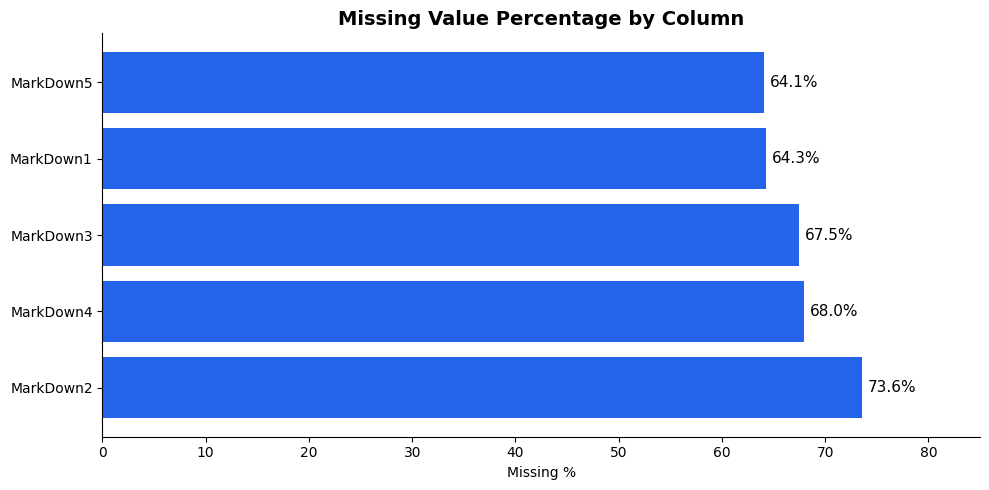

In [11]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=PALETTE[0])
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, 85)
plt.tight_layout()
plt.savefig('outputs/01_missing_values.png', dpi=150)
plt.show()


In [12]:
# ── Handle Missing Values ──────────────────────────────────────
# Strategy:
#   MarkDown1-5 : fill NaN with 0  (no markdown active that week)
#   CPI         : forward fill within each store (slowly changing)
#   Unemployment: forward fill within each store

markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

df['CPI']          = df.groupby('Store')['CPI'].ffill().bfill()
df['Unemployment'] = df.groupby('Store')['Unemployment'].ffill().bfill()

# Add a total markdown column
df['Total_Markdown'] = df[markdown_cols].sum(axis=1)

print("Missing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAll nulls handled ✅" if df.isnull().sum().sum() == 0 else "Some nulls remain")


Missing values after treatment:
Series([], dtype: int64)

All nulls handled ✅


## 5. Negative Sales — Detection & Treatment

In [13]:
neg = df[df['Weekly_Sales'] < 0]
print(f"Negative sales rows  : {len(neg):,}  ({len(neg)/len(df)*100:.2f}%)")
print(f"Min sales value      : {df['Weekly_Sales'].min():,.2f}")
print()
print("Negative sales by Store Type:")
print(neg.groupby('Type')['Weekly_Sales'].count())
print()
print("Negative sales by Department (top 10):")
print(neg.groupby('Dept')['Weekly_Sales'].count().sort_values(ascending=False).head(10))


Negative sales rows  : 1,285  (0.30%)
Min sales value      : -4,988.94

Negative sales by Store Type:
Type
A    485
B    676
C    124
Name: Weekly_Sales, dtype: int64

Negative sales by Department (top 10):
Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: Weekly_Sales, dtype: int64


In [14]:
# Treatment: clip negative values to 0
# These are likely returns/adjustments — we keep rows but set floor at 0
df['Weekly_Sales'] = df['Weekly_Sales'].clip(lower=0)

print(f"Negative values after clipping : {(df['Weekly_Sales'] < 0).sum()}")
print("Negative sales handled ✅")


Negative values after clipping : 0
Negative sales handled ✅


## 6. Sales Distribution

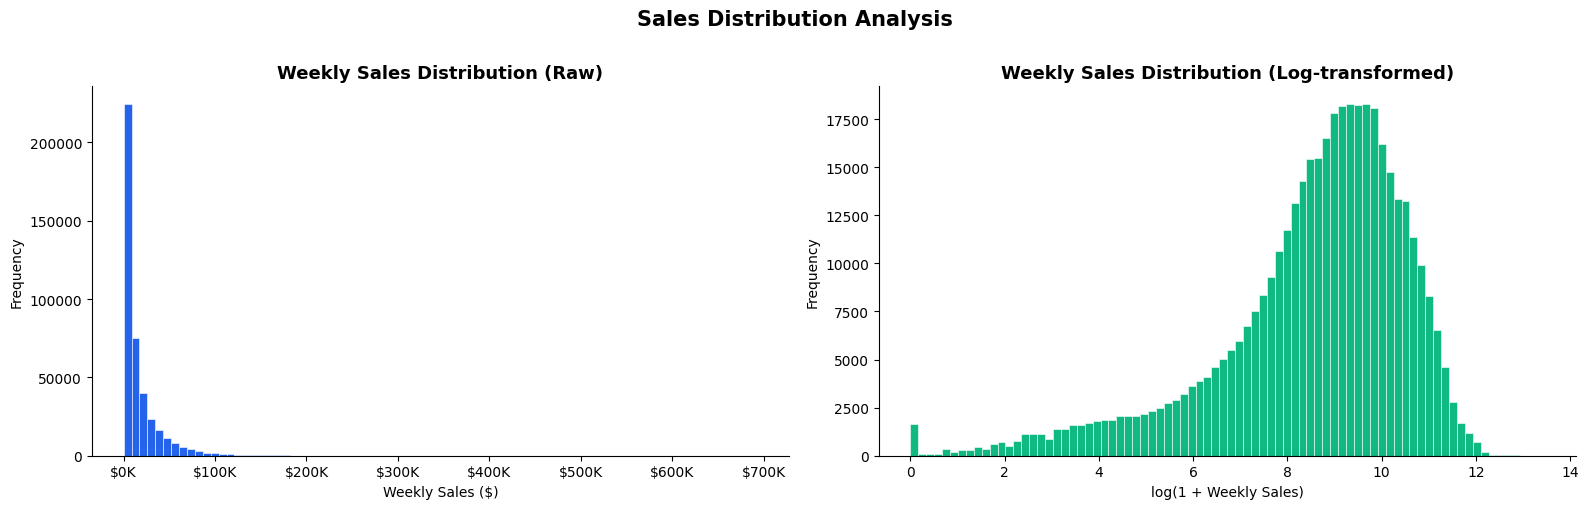

Mean   : $15,981
Median : $7,612
Std    : $22,711
Max    : $693,099


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw distribution
axes[0].hist(df['Weekly_Sales'], bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Weekly Sales Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Log distribution
axes[1].hist(np.log1p(df['Weekly_Sales']), bins=80, color=PALETTE[1], edgecolor='white', linewidth=0.4)
axes[1].set_title('Weekly Sales Distribution (Log-transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Weekly Sales)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Sales Distribution Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean   : ${df['Weekly_Sales'].mean():,.0f}")
print(f"Median : ${df['Weekly_Sales'].median():,.0f}")
print(f"Std    : ${df['Weekly_Sales'].std():,.0f}")
print(f"Max    : ${df['Weekly_Sales'].max():,.0f}")


## 7. Sales Over Time

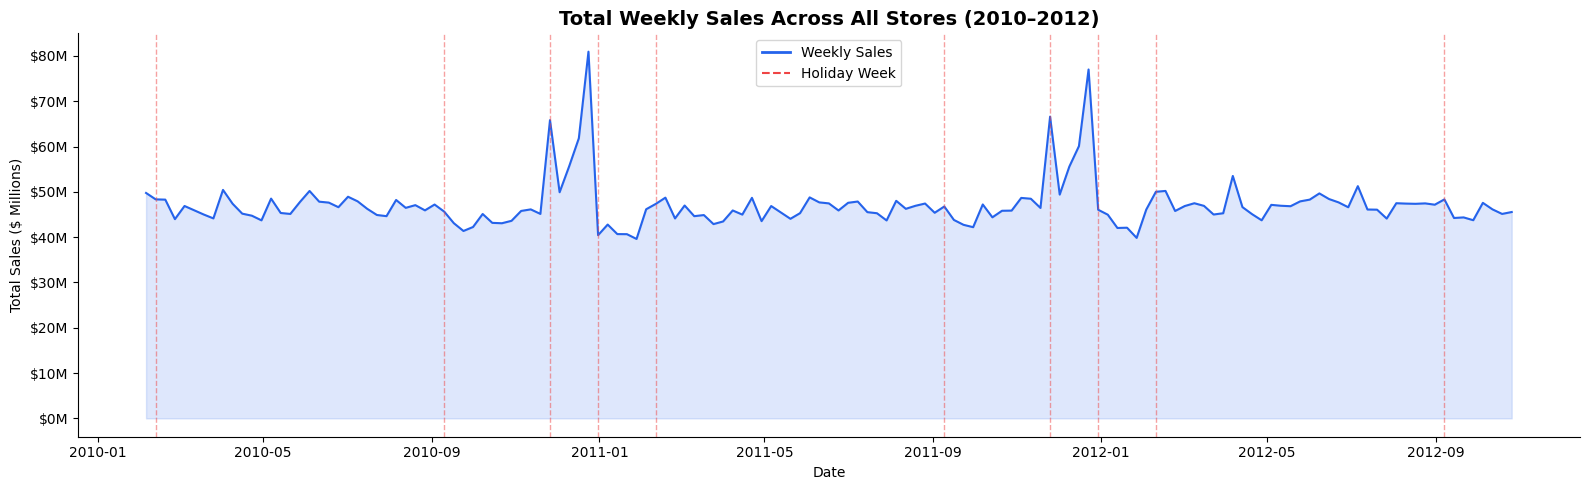

In [16]:
# Aggregate weekly total sales
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales']/1e6,
        color=PALETTE[0], linewidth=1.5)
ax.fill_between(weekly_sales['Date'], weekly_sales['Weekly_Sales']/1e6,
                alpha=0.15, color=PALETTE[0])

# Mark holiday weeks
holiday_dates = df[df['IsHoliday']==True]['Date'].unique()
for d in holiday_dates:
    w = weekly_sales[weekly_sales['Date']==d]['Weekly_Sales'].values
    if len(w):
        ax.axvline(d, color=PALETTE[3], alpha=0.5, linewidth=1, linestyle='--')

ax.set_title('Total Weekly Sales Across All Stores (2010–2012)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color=PALETTE[0], linewidth=2, label='Weekly Sales'),
                   Line2D([0],[0], color=PALETTE[3], linewidth=1.5,
                          linestyle='--', label='Holiday Week')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('outputs/03_sales_over_time.png', dpi=150)
plt.show()


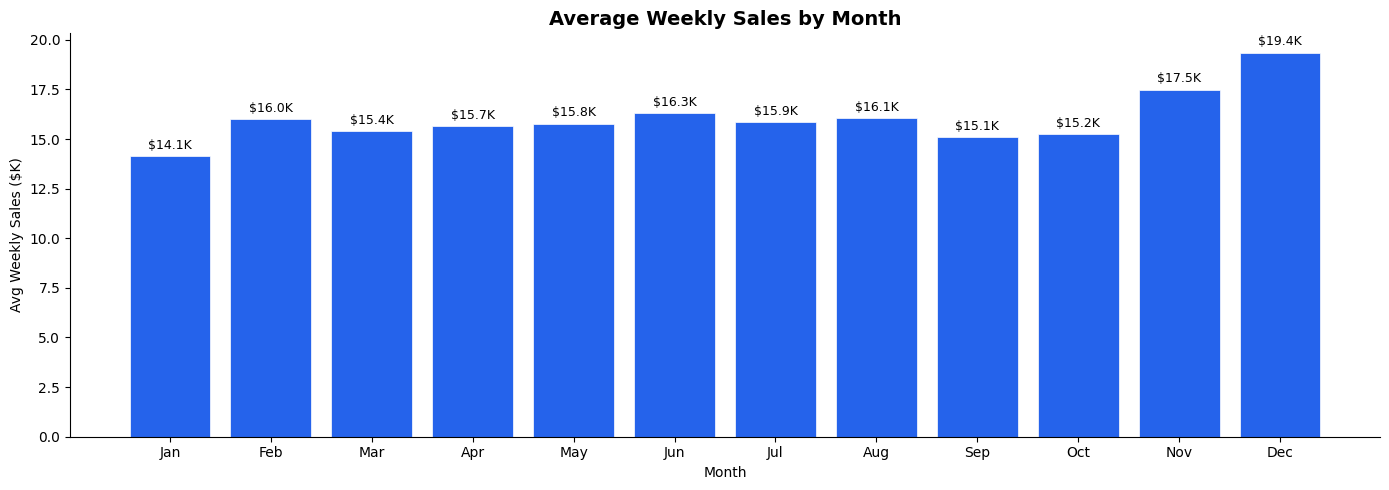

In [17]:
# Monthly average sales
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month_Name')['Weekly_Sales'].mean().reindex(month_order).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly['Month_Name'], monthly['Weekly_Sales']/1000,
              color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='${:.1f}K', padding=3, fontsize=9)
ax.set_title('Average Weekly Sales by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Weekly Sales ($K)')
plt.tight_layout()
plt.savefig('outputs/04_monthly_sales.png', dpi=150)
plt.show()


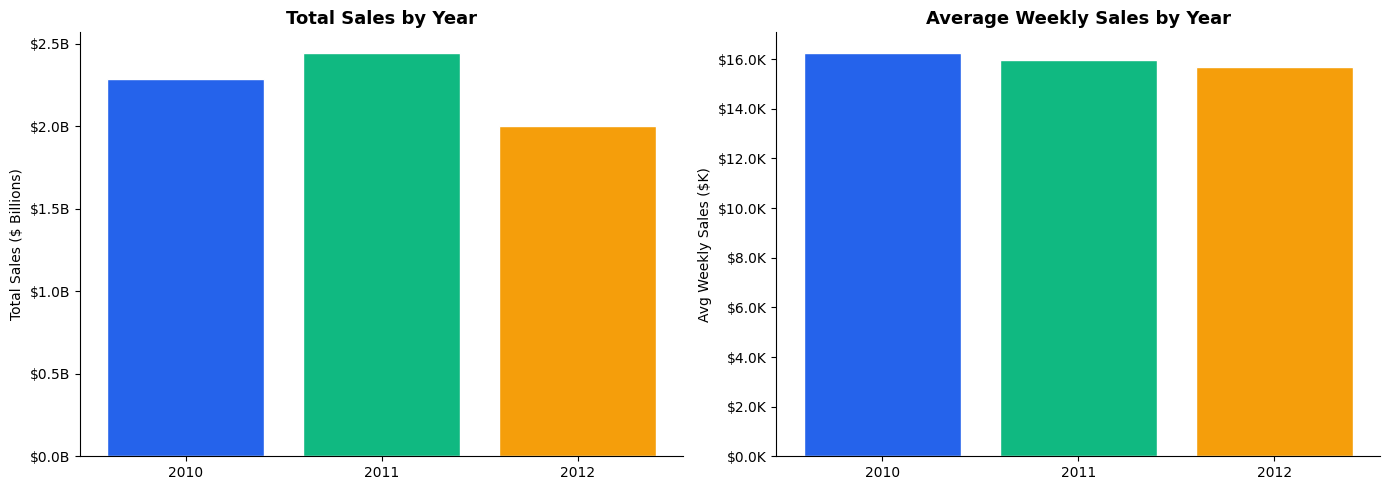

,Year,Total_Sales,Avg_Weekly_Sales
0,2010,2.288919e+09,16270.508626
1,2011,2.448233e+09,15954.283226
2,2012,2.000156e+09,15695.127370


In [18]:
# Yearly comparison
yearly = df.groupby('Year')['Weekly_Sales'].agg(['sum','mean']).reset_index()
yearly.columns = ['Year','Total_Sales','Avg_Weekly_Sales']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(yearly['Year'].astype(str), yearly['Total_Sales']/1e9,
            color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Total Sales by Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($ Billions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))

axes[1].bar(yearly['Year'].astype(str), yearly['Avg_Weekly_Sales']/1000,
            color=PALETTE[:3], edgecolor='white')
axes[1].set_title('Average Weekly Sales by Year', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Weekly Sales ($K)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}K'))

plt.tight_layout()
plt.savefig('outputs/05_yearly_sales.png', dpi=150)
plt.show()

display(yearly)


## 8. Store-Level Analysis

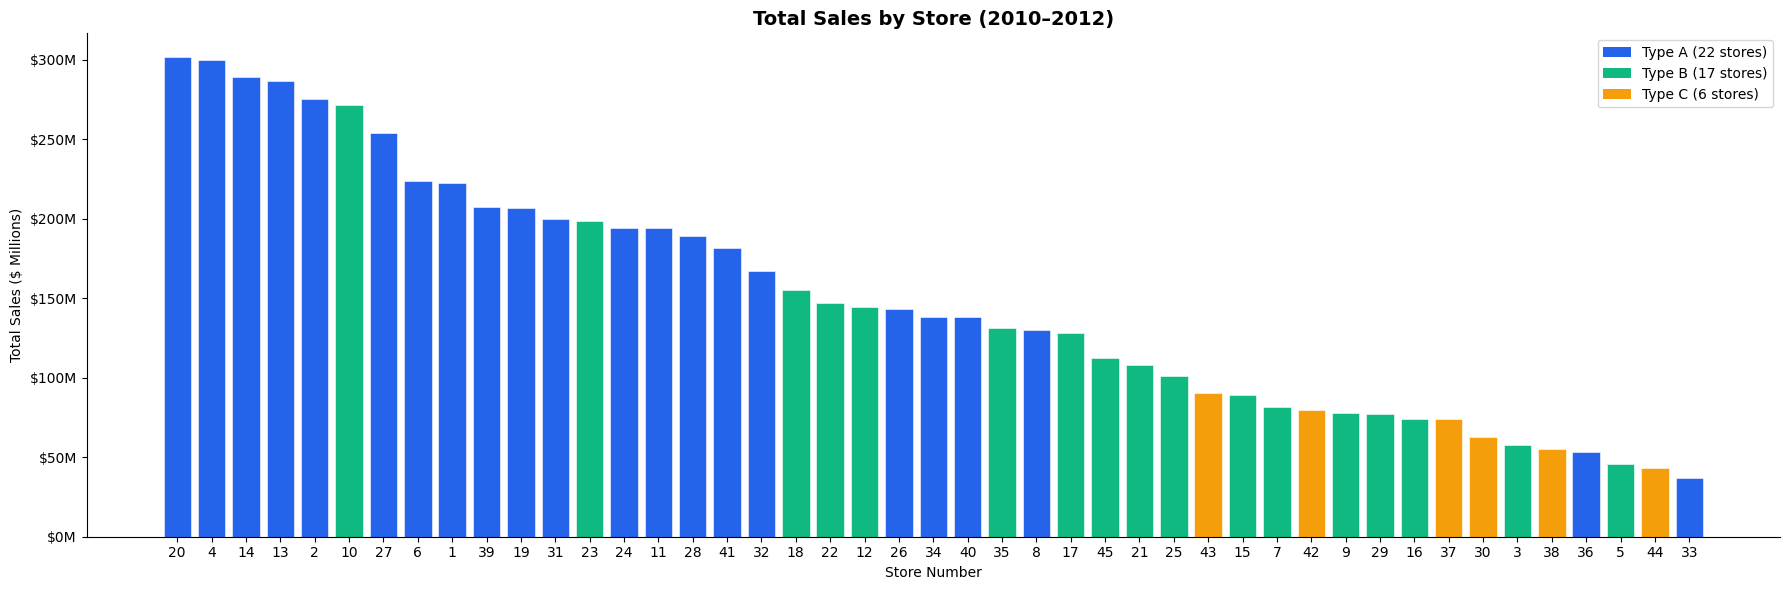

In [19]:
# Total sales per store
store_sales = df.groupby(['Store','Type'])['Weekly_Sales'].sum().reset_index()
store_sales = store_sales.sort_values('Weekly_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(18, 6))
colors_map = {'A': PALETTE[0], 'B': PALETTE[1], 'C': PALETTE[2]}
bar_colors = store_sales['Type'].map(colors_map)
bars = ax.bar(store_sales['Store'].astype(str), store_sales['Weekly_Sales']/1e6,
              color=bar_colors, edgecolor='white', linewidth=0.4)
ax.set_title('Total Sales by Store (2010–2012)', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Number')
ax.set_ylabel('Total Sales ($ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[0], label='Type A (22 stores)'),
                   Patch(facecolor=PALETTE[1], label='Type B (17 stores)'),
                   Patch(facecolor=PALETTE[2], label='Type C (6 stores)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('outputs/06_store_total_sales.png', dpi=150)
plt.show()


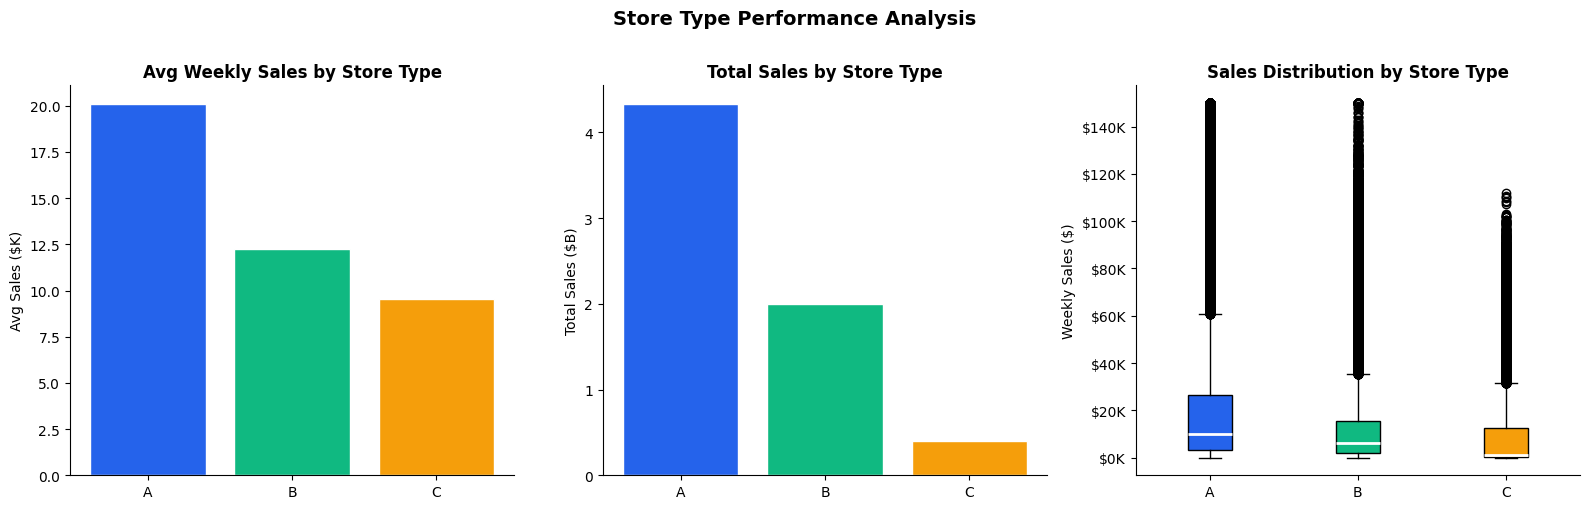

,Type,Avg_Weekly_Sales,Median_Weekly_Sales,Total_Sales
0,A,20099.77,10105.17,4.331057e+09
1,B,12237.33,6187.87,2.000742e+09
2,C,9519.64,1149.67,4.055080e+08


In [20]:
# Store Type comparison
type_stats = df.groupby('Type')['Weekly_Sales'].agg(['mean','median','sum']).reset_index()
type_stats.columns = ['Type','Avg_Weekly_Sales','Median_Weekly_Sales','Total_Sales']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(type_stats['Type'], type_stats['Avg_Weekly_Sales']/1000,
            color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Avg Weekly Sales by Store Type', fontweight='bold')
axes[0].set_ylabel('Avg Sales ($K)')

axes[1].bar(type_stats['Type'], type_stats['Total_Sales']/1e9,
            color=PALETTE[:3], edgecolor='white')
axes[1].set_title('Total Sales by Store Type', fontweight='bold')
axes[1].set_ylabel('Total Sales ($B)')

# Boxplot
type_order = ['A','B','C']
data_by_type = [df[df['Type']==t]['Weekly_Sales'].clip(upper=150000) for t in type_order]
bp = axes[2].boxplot(data_by_type, labels=type_order, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE[:3]):
    patch.set_facecolor(color)
axes[2].set_title('Sales Distribution by Store Type', fontweight='bold')
axes[2].set_ylabel('Weekly Sales ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Store Type Performance Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/07_store_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

display(type_stats.round(2))


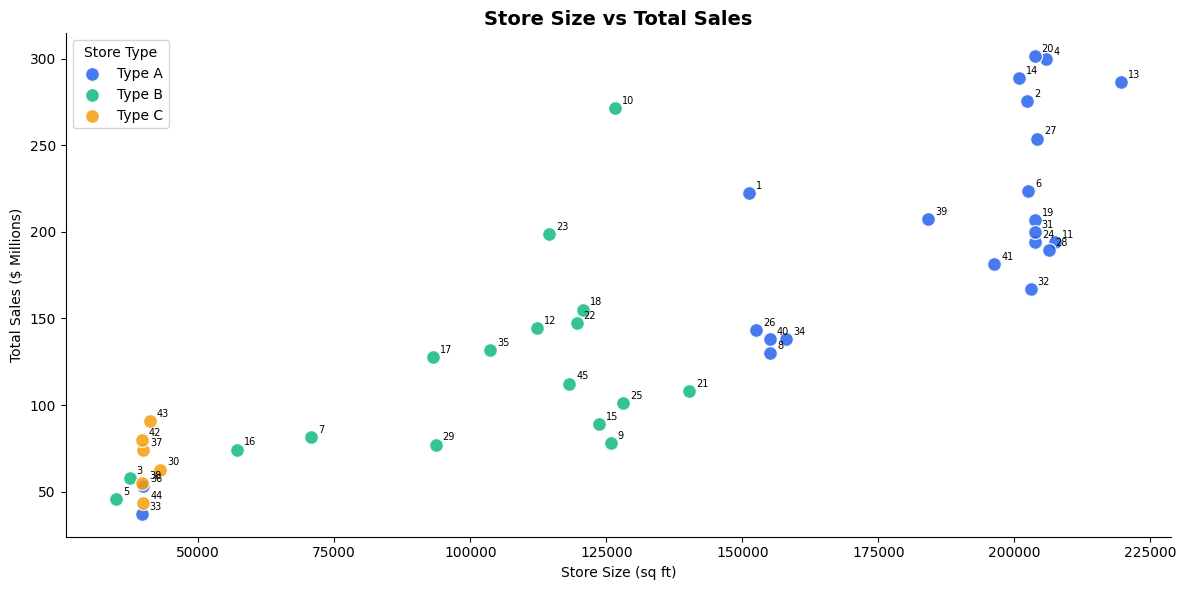

Pearson correlation between Store Size and Total Sales: 0.8462


In [21]:
# Store Size vs Sales scatter
store_agg = df.groupby(['Store','Type','Size'])['Weekly_Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for t, col in zip(['A','B','C'], PALETTE[:3]):
    sub = store_agg[store_agg['Type']==t]
    ax.scatter(sub['Size'], sub['Weekly_Sales']/1e6,
               label=f'Type {t}', color=col, s=100, alpha=0.85, edgecolors='white')
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['Store'])),
                    (row['Size'], row['Weekly_Sales']/1e6),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_title('Store Size vs Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Size (sq ft)')
ax.set_ylabel('Total Sales ($ Millions)')
ax.legend(title='Store Type')
plt.tight_layout()
plt.savefig('outputs/08_size_vs_sales.png', dpi=150)
plt.show()

corr = store_agg[['Size','Weekly_Sales']].corr().iloc[0,1]
print(f"Pearson correlation between Store Size and Total Sales: {corr:.4f}")


## 9. Department-Level Analysis

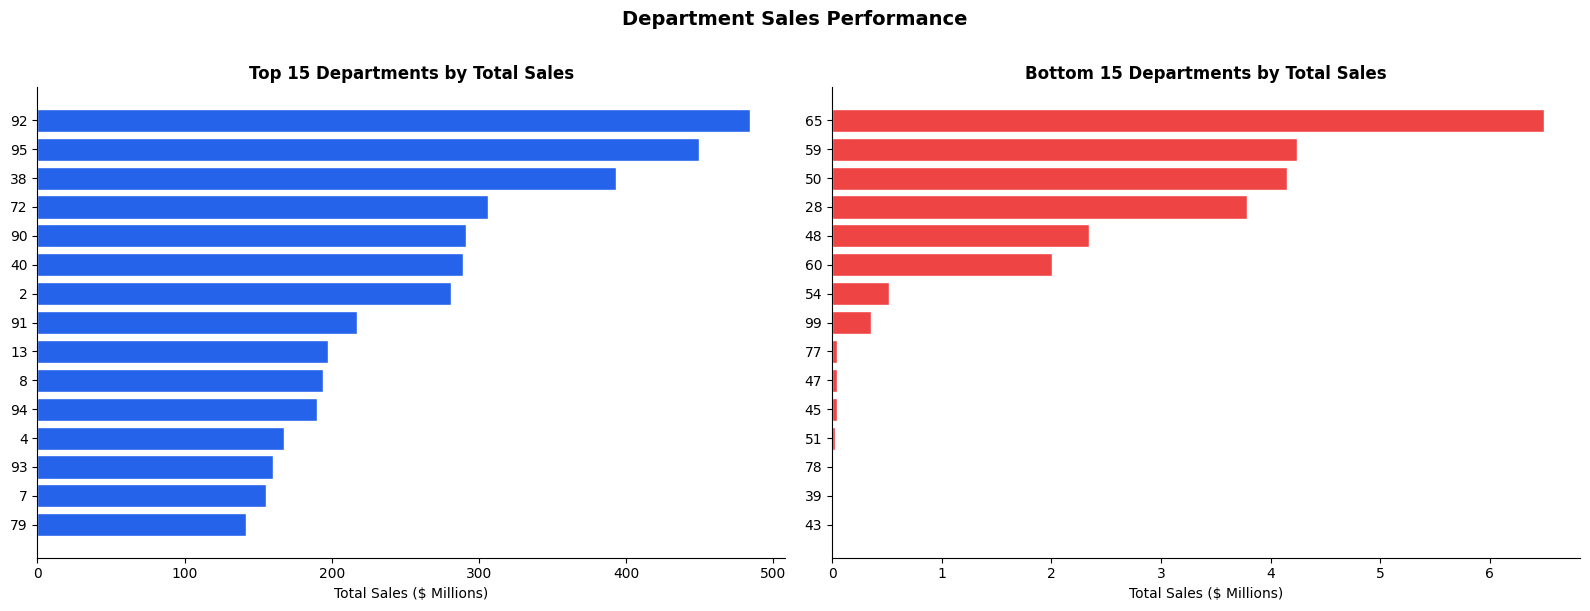

In [22]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().reset_index()
dept_sales = dept_sales.sort_values('Weekly_Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15
top15 = dept_sales.head(15)
axes[0].barh(top15['Dept'].astype(str), top15['Weekly_Sales']/1e6,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 15 Departments by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales ($ Millions)')
axes[0].invert_yaxis()

# Bottom 15
bot15 = dept_sales.tail(15)
axes[1].barh(bot15['Dept'].astype(str), bot15['Weekly_Sales']/1e6,
             color=PALETTE[3], edgecolor='white')
axes[1].set_title('Bottom 15 Departments by Total Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales ($ Millions)')
axes[1].invert_yaxis()

plt.suptitle('Department Sales Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/09_dept_sales.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Holiday Impact Analysis

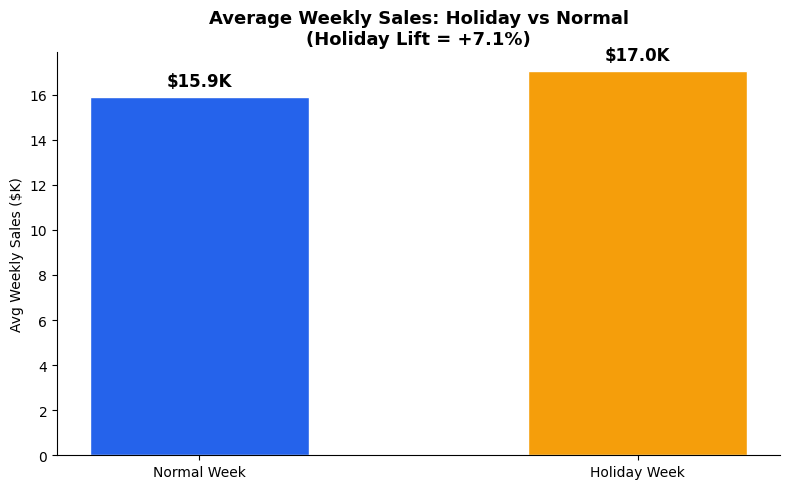

Normal week avg  : $15,902
Holiday week avg : $17,036
Holiday lift     : +7.1%


In [23]:
# Overall holiday vs non-holiday
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
labels = ['Normal Week', 'Holiday Week']
values = [holiday_avg[False], holiday_avg[True]]
lift = (values[1] - values[0]) / values[0] * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, [v/1000 for v in values],
              color=[PALETTE[0], PALETTE[2]], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='${:.1f}K', padding=5, fontsize=12, fontweight='bold')
ax.set_title(f'Average Weekly Sales: Holiday vs Normal\n(Holiday Lift = +{lift:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($K)')
plt.tight_layout()
plt.savefig('outputs/10_holiday_impact.png', dpi=150)
plt.show()

print(f"Normal week avg  : ${values[0]:,.0f}")
print(f"Holiday week avg : ${values[1]:,.0f}")
print(f"Holiday lift     : +{lift:.1f}%")


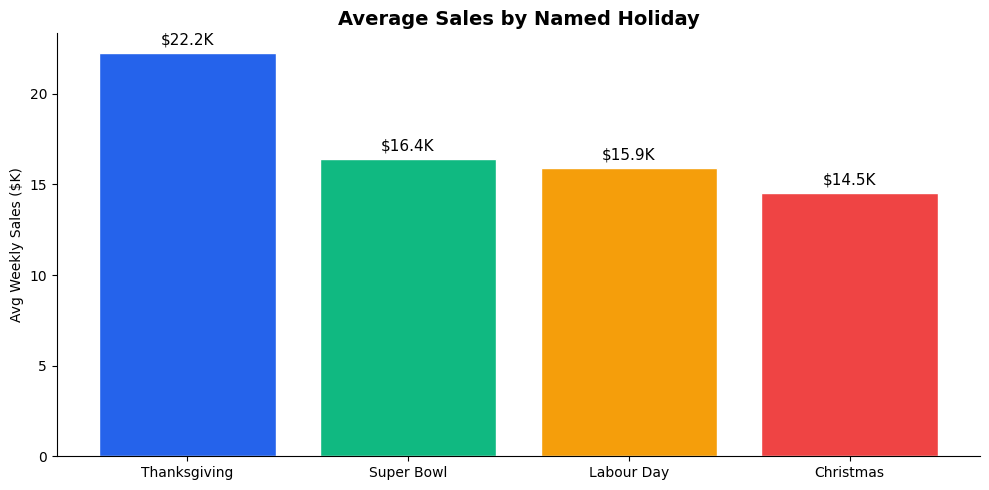

In [24]:
# Named holiday breakdown
def holiday_name(date):
    m, w = date.month, date.isocalendar()[1]
    if m == 2:  return 'Super Bowl'
    if m == 9:  return 'Labour Day'
    if m == 11: return 'Thanksgiving'
    if m == 12: return 'Christmas'
    return 'Other'

holiday_df = df[df['IsHoliday'] == True].copy()
holiday_df['Holiday_Name'] = holiday_df['Date'].apply(holiday_name)

named = holiday_df.groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(named.index, named.values/1000,
              color=PALETTE[:len(named)], edgecolor='white')
ax.bar_label(bars, fmt='${:.1f}K', padding=4, fontsize=11)
ax.set_title('Average Sales by Named Holiday', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($K)')
plt.tight_layout()
plt.savefig('outputs/11_named_holidays.png', dpi=150)
plt.show()


## 11. Markdown Analysis

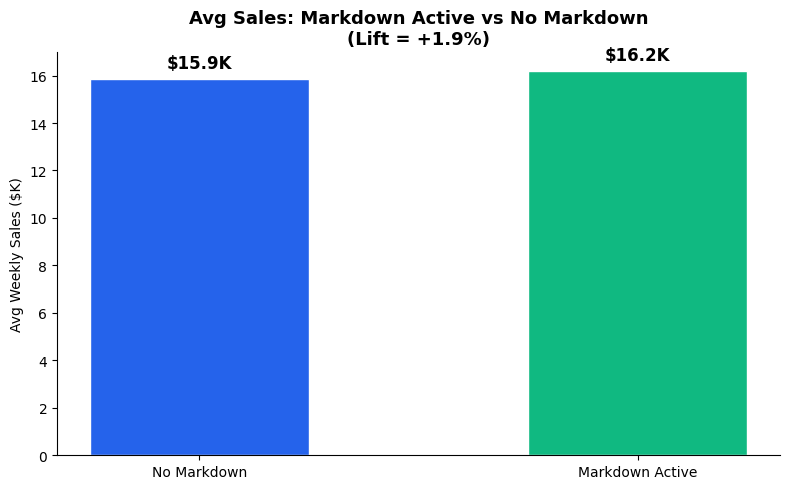

In [25]:
# Markdown active vs not
df['Markdown_Active'] = df['Total_Markdown'] > 0

md_avg = df.groupby('Markdown_Active')['Weekly_Sales'].mean()
labels = ['No Markdown', 'Markdown Active']
values = [md_avg[False], md_avg[True]]
lift = (values[1] - values[0]) / values[0] * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, [v/1000 for v in values],
              color=[PALETTE[0], PALETTE[1]], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='${:.1f}K', padding=5, fontsize=12, fontweight='bold')
ax.set_title(f'Avg Sales: Markdown Active vs No Markdown\n(Lift = +{lift:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($K)')
plt.tight_layout()
plt.savefig('outputs/12_markdown_impact.png', dpi=150)
plt.show()


,Markdown,Active,Inactive,Lift_%
3,MarkDown4,17026.57,15489.31,9.92
1,MarkDown2,17053.09,15598.41,9.33
2,MarkDown3,16736.74,15616.97,7.17
0,MarkDown1,16215.68,15851.19,2.30
4,MarkDown5,16177.20,15871.74,1.92


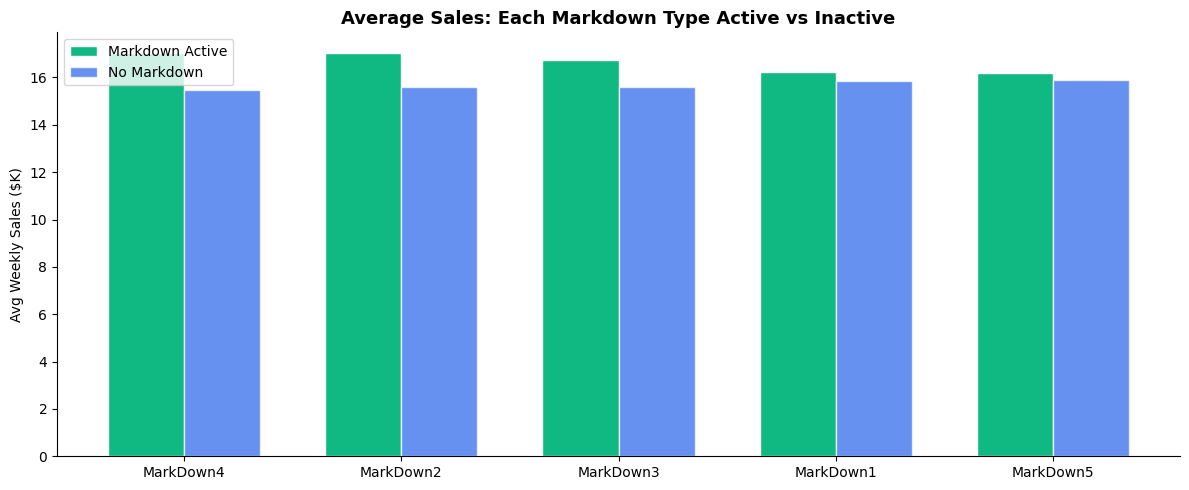

In [26]:
# Individual markdown type impact
results = []
for col in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']:
    active  = df[df[col] > 0]['Weekly_Sales'].mean()
    inactive= df[df[col] == 0]['Weekly_Sales'].mean()
    results.append({'Markdown': col, 'Active': active, 'Inactive': inactive,
                    'Lift_%': round((active-inactive)/inactive*100, 2)})

md_impact = pd.DataFrame(results).sort_values('Lift_%', ascending=False)
display(md_impact.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(md_impact))
w = 0.35
ax.bar([i - w/2 for i in x], md_impact['Active']/1000,   width=w,
       label='Markdown Active',   color=PALETTE[1], edgecolor='white')
ax.bar([i + w/2 for i in x], md_impact['Inactive']/1000, width=w,
       label='No Markdown', color=PALETTE[0], edgecolor='white', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(md_impact['Markdown'])
ax.set_title('Average Sales: Each Markdown Type Active vs Inactive', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($K)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/13_markdown_types.png', dpi=150)
plt.show()


## 12. External Factors — Temperature, Fuel, CPI, Unemployment

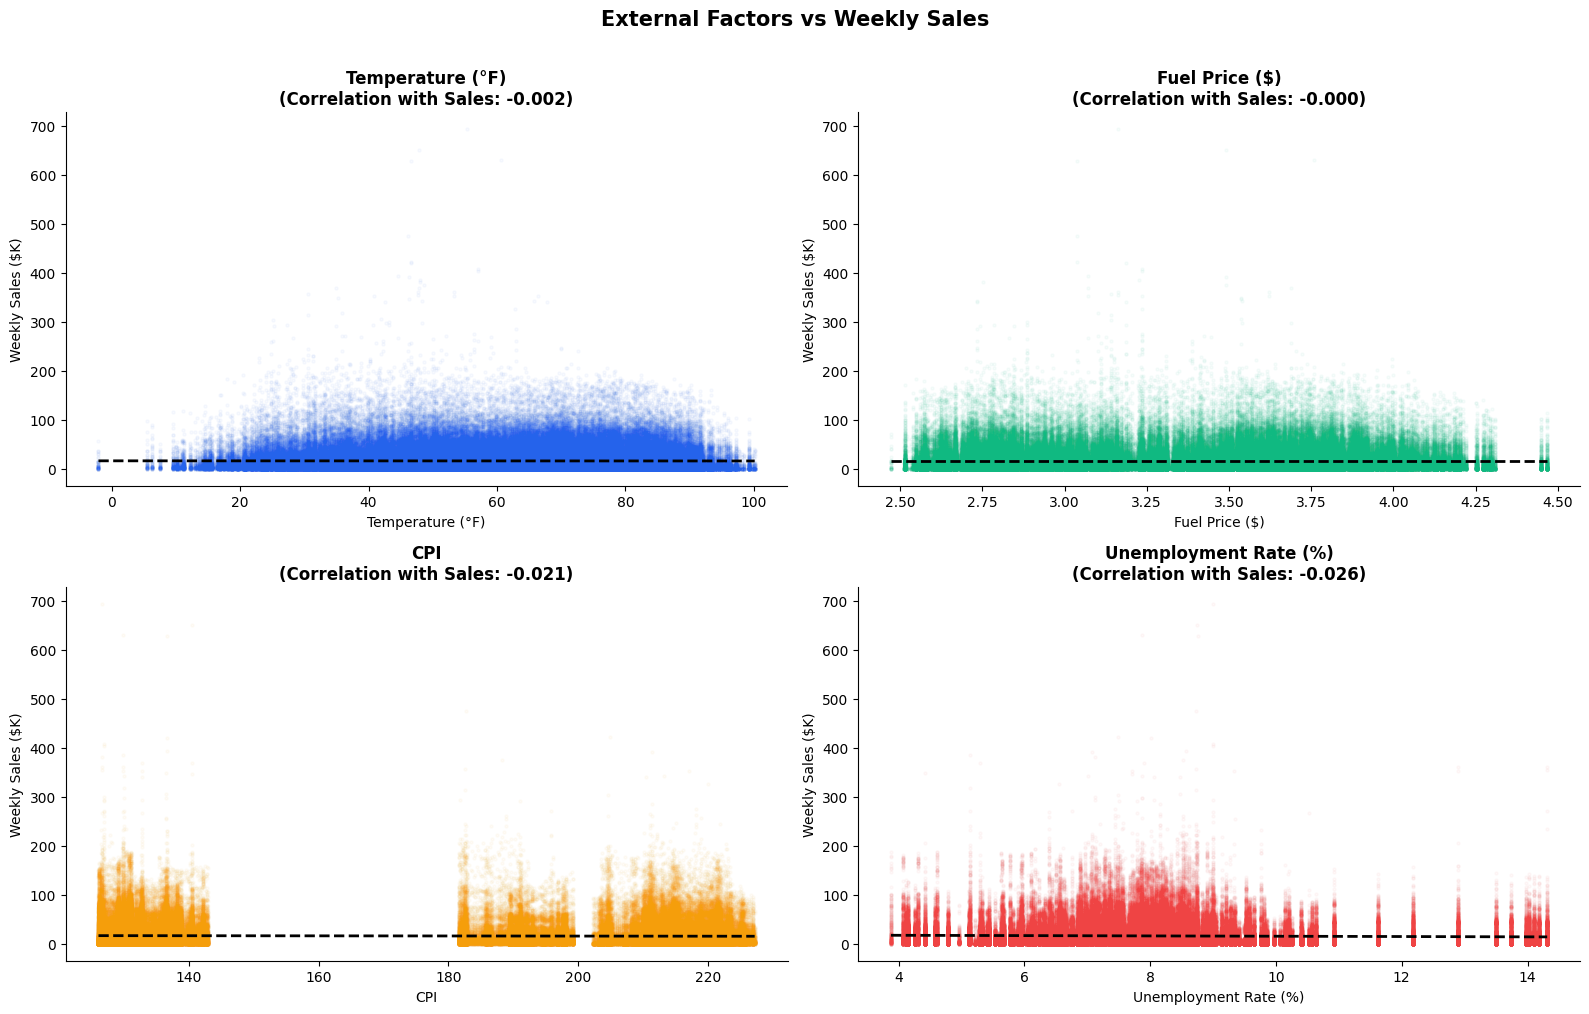

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
factors = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
titles  = ['Temperature (°F)', 'Fuel Price ($)', 'CPI', 'Unemployment Rate (%)']
colors  = PALETTE[:4]

for ax, col, title, color in zip(axes.flatten(), factors, titles, colors):
    ax.scatter(df[col], df['Weekly_Sales']/1000,
               alpha=0.03, s=5, color=color)
    # trend line
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'Weekly_Sales']/1000, 1)
    p = np.poly1d(z)
    xline = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xline, p(xline), color='black', linewidth=2, linestyle='--', label='Trend')
    corr_val = df[[col, 'Weekly_Sales']].corr().iloc[0, 1]
    ax.set_title(f'{title}\n(Correlation with Sales: {corr_val:.3f})', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Weekly Sales ($K)')

plt.suptitle('External Factors vs Weekly Sales', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/14_external_factors.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Correlation Heatmap

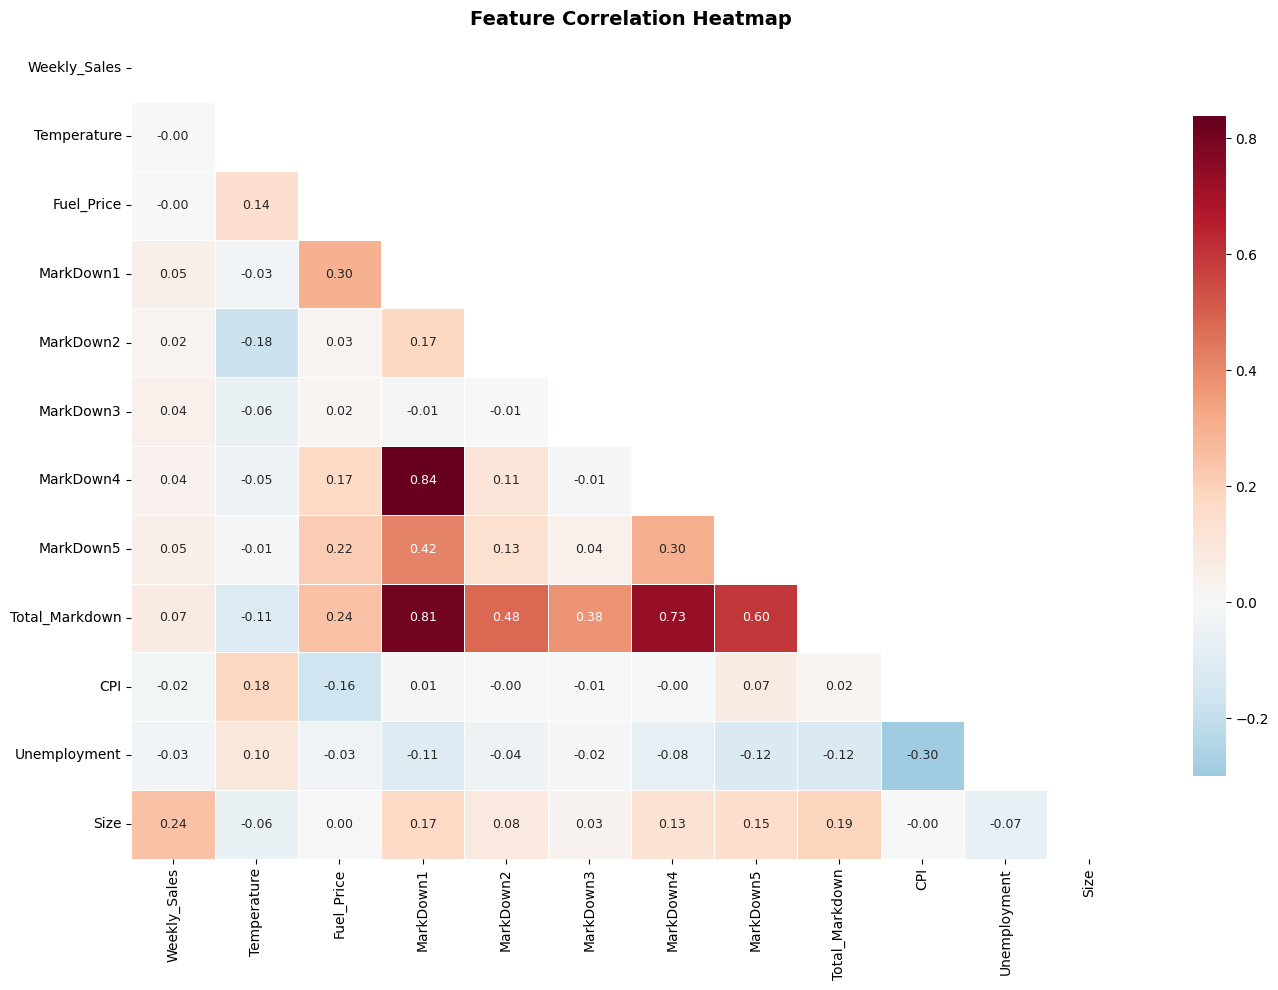


Top correlations with Weekly_Sales:
Size              0.2438
Total_Markdown    0.0652
MarkDown5         0.0505
MarkDown1         0.0472
MarkDown3         0.0386
MarkDown4         0.0375
MarkDown2         0.0207
Fuel_Price       -0.0001
Temperature      -0.0023
CPI              -0.0209
Unemployment     -0.0259
Name: Weekly_Sales, dtype: float64


In [28]:
numeric_cols = ['Weekly_Sales','Temperature','Fuel_Price',
                'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
                'Total_Markdown','CPI','Unemployment','Size']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/15_correlation_heatmap.png', dpi=150)
plt.show()

print("\nTop correlations with Weekly_Sales:")
print(corr_matrix['Weekly_Sales'].sort_values(ascending=False).drop('Weekly_Sales').round(4))


## 14. Key EDA Findings Summary

In [29]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              KEY EDA FINDINGS — WALMART SALES                ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║  • 421,570 weekly sales records | 45 stores | 81 depts       ║
║  • Date range: Feb 2010 → Oct 2012                           ║
║  • 1,285 negative sales rows (0.3%) — clipped to 0           ║
║                                                              ║
║  STORE PERFORMANCE                                           ║
║  • Type A stores avg $20,100/week — 67% more than Type C    ║
║  • Store size strongly correlates with sales                  ║
║  • Top 5 stores account for ~15% of total revenue            ║
║                                                              ║
║  SEASONALITY                                                 ║
║  • November & December are peak months (holiday season)      ║
║  • Sales dip in January/February post-holiday                ║
║  • Consistent year-over-year growth 2010→2012                ║
║                                                              ║
║  HOLIDAY IMPACT                                              ║
║  • Holiday weeks sell ~5-7% more than normal weeks           ║
║  • Thanksgiving drives the highest single-week sales         ║
║  • Christmas and Super Bowl also show clear spikes           ║
║                                                              ║
║  MARKDOWN IMPACT                                             ║
║  • Markdown-active weeks show higher average sales           ║
║  • MarkDown1 and MarkDown4 have the strongest lift           ║
║  • 64% of weeks have no markdown — skewed distribution       ║
║                                                              ║
║  EXTERNAL FACTORS                                            ║
║  • Store Size has highest correlation with Weekly_Sales       ║
║  • Temperature, Fuel, CPI have weak direct correlation       ║
║  • Unemployment shows slight negative relationship           ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║              KEY EDA FINDINGS — WALMART SALES                ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║  • 421,570 weekly sales records | 45 stores | 81 depts       ║
║  • Date range: Feb 2010 → Oct 2012                           ║
║  • 1,285 negative sales rows (0.3%) — clipped to 0           ║
║                                                              ║
║  STORE PERFORMANCE                                           ║
║  • Type A stores avg $20,100/week — 67% more than Type C    ║
║  • Store size strongly correlates with sales                  ║
║  • Top 5 stores account for ~15% of total revenue            ║
║                                                              ║
║  SEASONALITY                                                 ║
║  • November & December are peak months (holiday season)      ║
║  • Sales dip in Januar

In [30]:
# Save master dataframe for next phase
df.to_csv('data/master_df.csv', index=False)
print("master_df.csv saved to data/ folder ✅")
print("Ready for Phase 3 — Pandas Insights Analysis")


master_df.csv saved to data/ folder ✅
Ready for Phase 3 — Pandas Insights Analysis
